## Part 3: Decoherence (T1 and T2)

Every simulation so far, Trotterisation, entanglement growth, Rabi 
control, assumed a closed, perfectly isolated qubit evolving unitarily. 
Real qubits are never fully isolated: coupling to their environment 
causes energy relaxation (T1) and loss of phase coherence (T2). This 
notebook implements the Lindblad master equation, the standard 
description of this open-system evolution, validates it against known 
analytic decay laws, and discusses how T1/T2 relate to the gate time 
derived in the Rabi notebook.

### Setting up the Lindblad master equation

A qubit's population decay (T1) and coherence decay (T2) are captured by 
two Lindblad operators: a lowering operator for energy relaxation, and a 
Z-based operator for pure dephasing. Starting from an equal superposition, 
both effects are visible simultaneously, population relaxing toward |0⟩, 
and coherence (the off-diagonal density matrix element) decaying 
independently. H is set to zero here (the rotating frame), isolating the 
decay itself from any drive or precession.

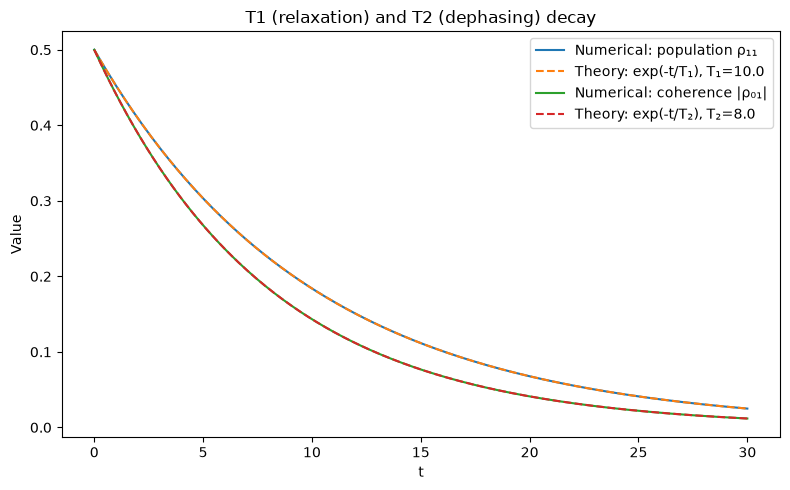

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Z = np.array([[1, 0], [0, -1]], dtype=complex)
sigma_minus = np.array([[0, 1], [0, 0]], dtype=complex)   # |1> -> |0>

T1 = 10.0
T2 = 8.0    # must satisfy T2 <= 2*T1
gamma1 = 1/T1
gamma_phi = 1/T2 - 1/(2*T1)   # pure dephasing rate, on top of T1's own contribution to T2

L1 = np.sqrt(gamma1) * sigma_minus
L2 = np.sqrt(gamma_phi/2) * Z

def lindblad_rhs(t, rho_flat):
    rho = rho_flat[:4].reshape(2,2) + 1j*rho_flat[4:].reshape(2,2)
    def D(L, rho):
        return L @ rho @ L.conj().T - 0.5*(L.conj().T @ L @ rho + rho @ L.conj().T @ L)
    drho = D(L1, rho) + D(L2, rho)   # H=0, no unitary term (rotating frame)
    return np.concatenate([drho.real.flatten(), drho.imag.flatten()])

# Initial state: equal superposition, so both population and coherence are visible
psi0 = np.array([1, 1], dtype=complex) / np.sqrt(2)
rho0 = np.outer(psi0, psi0.conj())
y0 = np.concatenate([rho0.real.flatten(), rho0.imag.flatten()])

t_eval = np.linspace(0, 30, 300)
sol = solve_ivp(lindblad_rhs, (0, 30), y0, t_eval=t_eval, rtol=1e-9, atol=1e-9)

pop1 = np.array([(sol.y[:4,i].reshape(2,2)+1j*sol.y[4:,i].reshape(2,2))[1,1].real for i in range(len(t_eval))])
coherence = np.array([abs((sol.y[:4,i].reshape(2,2)+1j*sol.y[4:,i].reshape(2,2))[0,1]) for i in range(len(t_eval))])

pop1_theory = 0.5*np.exp(-t_eval/T1)
coh_theory = 0.5*np.exp(-t_eval/T2)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(t_eval, pop1, label='Numerical: population ρ₁₁')
ax.plot(t_eval, pop1_theory, '--', label=f'Theory: exp(-t/T₁), T₁={T1}')
ax.plot(t_eval, coherence, label='Numerical: coherence |ρ₀₁|')
ax.plot(t_eval, coh_theory, '--', label=f'Theory: exp(-t/T₂), T₂={T2}')
ax.set_xlabel('t')
ax.set_ylabel('Value')
ax.set_title('T1 (relaxation) and T2 (dephasing) decay')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/t1_t2_decay.png', dpi=120)

Both curves match their analytic predictions, exp(-t/T1) for population, 
exp(-t/T2) for coherence, essentially exactly, confirming the Lindblad 
implementation is correct.

### Comparing to the Rabi gate time

Using the optimal gate time derived in the Rabi notebook (Ω* ≈ 0.72, 
giving π/Ω* ≈ 4.37), the number of gates performable before significant 
decay gives a rough sense of how T1/T2 constrain usable circuit depth.

In [2]:
gate_time = np.pi / 0.7185   # your optimal gate time from the Rabi tradeoff analysis

n_gates_before_T1 = T1 / gate_time
n_gates_before_T2 = T2 / gate_time

print(f"Optimal single-qubit gate time: {gate_time:.3f}")
print(f"Number of gates before significant T1 decay: {n_gates_before_T1:.1f}")
print(f"Number of gates before significant T2 decay: {n_gates_before_T2:.1f}")

Optimal single-qubit gate time: 4.372
Number of gates before significant T1 decay: 2.3
Number of gates before significant T2 decay: 1.8


With these illustrative T1, T2 values, this qubit survives only about 
2 gate operations before losing meaningful coherence, a poor ratio. This 
motivates asking how real hardware achieves usable coherence-to-gate-time 
ratios, addressed below.

## Connecting to real hardware

The T1, T2 values used above were chosen illustratively in the project's 
natural units, purely to produce a clear, visible decay curve, not 
calibrated to any specific device. For real-world context: current 
superconducting qubits report coherence times of 50–300 microseconds, 
with record devices now exceeding 1 millisecond (e.g. Princeton, 2025), 
against typical gate times of 10–50 nanoseconds. This gives real 
coherence-to-gate-time ratios of roughly 1,000–10,000+, the actual 
engineering margin that makes deep quantum circuits possible before 
decoherence dominates. This project's own numbers were not intended 
to reproduce this ratio, only to validate the underlying Lindblad 
decay physics.